---
Phase 5-LLM-2: LLM 全景 — BERT / GPT / LLaMA / 生成策略
---

大型語言模型 (LLM) 的發展歷程：
  2018: BERT (Google) — 雙向理解
  2019: GPT-2 (OpenAI) — 開放生成
  2020: GPT-3 — 175B 參數，In-context Learning
  2023: LLaMA (Meta) — 開源 LLM
  2023: GPT-4 — 多模態
  2024: Claude, LLaMA-3, Gemini, ...

本檔涵蓋：
  1. BERT — 理解型 (Encoder)
  2. GPT — 生成型 (Decoder)
  3. 預訓練策略 (MLM / CLM)
  4. In-Context Learning & Prompting
  5. 生成策略 (Greedy / Beam / Sampling)
  6. LLM 全景圖

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. BERT — 理解型 LM
# ============================================================================

In [2]:
print("=" * 60)
print("1. BERT — 雙向理解")
print("=" * 60)

print("""
BERT (Bidirectional Encoder Representations from Transformers)

  架構：Transformer Encoder（雙向 attention）
  預訓練任務：
    1. MLM (Masked Language Model):
       輸入: "The [MASK] sat on the mat"
       目標: 預測 [MASK] = "cat"
       → 迫使模型理解上下文

    2. NSP (Next Sentence Prediction):
       句子 A + 句子 B → 判斷 B 是不是 A 的下一句
       （後來發現這個任務幫助不大）

  特點：
  - 雙向：每個 token 可以看到前後文
  - 不能直接生成（因為雙向）
  - 擅長理解任務：分類、NER、問答

  使用方式：
  1. 預訓練（在大量文字上學通用表示）
  2. 微調（在特定任務上加一個分類頭）
""")

# 模擬 BERT 的 MLM
print("--- 模擬 MLM 訓練 ---")

vocab = ['<PAD>', '<MASK>', 'the', 'cat', 'dog', 'sat', 'on', 'mat',
         'ran', 'in', 'park', 'is', 'big', 'small']
w2i = {w: i for i, w in enumerate(vocab)}

sentence = ['the', 'cat', 'sat', 'on', 'the', 'mat']
print(f"原句: {sentence}")

# 隨機 mask 15% 的 token
np.random.seed(42)
masked = sentence.copy()
labels = [-100] * len(sentence)  # -100 = 不計算 loss

for i in range(len(masked)):
    if np.random.random() < 0.3:  # 30%（因為句子短）
        labels[i] = w2i[masked[i]]
        if np.random.random() < 0.8:
            masked[i] = '<MASK>'        # 80% 替換為 [MASK]
        elif np.random.random() < 0.5:
            masked[i] = np.random.choice(vocab[2:])  # 10% 隨機詞
        # 10% 保持不變

print(f"Masked: {masked}")
print(f"Labels: {labels}")
print("→ 模型要預測被 mask 的位置原來是什麼")

1. BERT — 雙向理解

BERT (Bidirectional Encoder Representations from Transformers)

  架構：Transformer Encoder（雙向 attention）
  預訓練任務：
    1. MLM (Masked Language Model):
       輸入: "The [MASK] sat on the mat"
       目標: 預測 [MASK] = "cat"
       → 迫使模型理解上下文

    2. NSP (Next Sentence Prediction):
       句子 A + 句子 B → 判斷 B 是不是 A 的下一句
       （後來發現這個任務幫助不大）

  特點：
  - 雙向：每個 token 可以看到前後文
  - 不能直接生成（因為雙向）
  - 擅長理解任務：分類、NER、問答

  使用方式：
  1. 預訓練（在大量文字上學通用表示）
  2. 微調（在特定任務上加一個分類頭）

--- 模擬 MLM 訓練 ---
原句: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Masked: ['the', 'cat', 'sat', 'on', '<MASK>', 'mat']
Labels: [-100, -100, -100, -100, 2, 7]
→ 模型要預測被 mask 的位置原來是什麼


## 2. GPT — 生成型 LM

In [3]:
print("\n" + "=" * 60)
print("2. GPT — 自迴歸生成")
print("=" * 60)

print("""
GPT (Generative Pre-trained Transformer)

  架構：Transformer Decoder（causal attention）
  預訓練任務：
    CLM (Causal Language Modeling):
    給前面的 tokens，預測下一個 token
    P(x_t | x_1, x_2, ..., x_{t-1})

  訓練：
    輸入: "The cat sat on the"
    目標: "cat sat on the mat"
    （每個位置預測下一個 token）

  生成：
    "The" → "cat" → "sat" → "on" → ...

  特點：
  - 單向：只看過去（causal mask）
  - 天生適合生成
  - GPT-3 發現了 In-Context Learning
""")


2. GPT — 自迴歸生成

GPT (Generative Pre-trained Transformer)

  架構：Transformer Decoder（causal attention）
  預訓練任務：
    CLM (Causal Language Modeling):
    給前面的 tokens，預測下一個 token
    P(x_t | x_1, x_2, ..., x_{t-1})

  訓練：
    輸入: "The cat sat on the"
    目標: "cat sat on the mat"
    （每個位置預測下一個 token）

  生成：
    "The" → "cat" → "sat" → "on" → ...

  特點：
  - 單向：只看過去（causal mask）
  - 天生適合生成
  - GPT-3 發現了 In-Context Learning



## 3. BERT vs GPT 比較

In [4]:
print("=" * 60)
print("3. BERT vs GPT 深度比較")
print("=" * 60)

print("""
  特性           BERT              GPT
  ─────────────────────────────────────────────
  架構           Encoder           Decoder
  Attention     雙向               單向 (causal)
  預訓練         MLM + NSP         CLM (next token)
  生成能力       不能               天生就是生成
  理解能力       很強               也很強（大了之後）
  典型用法       微調               Prompting / 微調
  參數量         110M-340M         125M-175B+

  現在的趨勢：
  GPT 類 (Decoder-Only) 已經大一統
  → 模型夠大時，decoder-only 也能做理解任務
  → Claude, GPT-4, LLaMA 都是 decoder-only
""")

# 用簡單模型展示 MLM vs CLM
class TinyBERT(nn.Module):
    """極簡 BERT（只為展示 MLM）"""
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=64,
            dropout=0.1, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.encoder(x)
        return self.head(x)


class TinyGPT(nn.Module):
    """極簡 GPT（展示 CLM）"""
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2, max_len=50):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=64,
            dropout=0.1, batch_first=True
        )
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def forward(self, x):
        B, T = x.shape
        tok = self.embedding(x)
        pos = self.pos_emb(torch.arange(T, device=x.device))
        x = tok + pos
        # Causal mask
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        x = self.decoder(x, mask=mask)
        return self.head(x)


bert = TinyBERT(len(vocab))
gpt = TinyGPT(len(vocab))
print(f"TinyBERT 參數: {sum(p.numel() for p in bert.parameters()):,}")
print(f"TinyGPT 參數:  {sum(p.numel() for p in gpt.parameters()):,}")

3. BERT vs GPT 深度比較

  特性           BERT              GPT
  ─────────────────────────────────────────────
  架構           Encoder           Decoder
  Attention     雙向               單向 (causal)
  預訓練         MLM + NSP         CLM (next token)
  生成能力       不能               天生就是生成
  理解能力       很強               也很強（大了之後）
  典型用法       微調               Prompting / 微調
  參數量         110M-340M         125M-175B+

  現在的趨勢：
  GPT 類 (Decoder-Only) 已經大一統
  → 模型夠大時，decoder-only 也能做理解任務
  → Claude, GPT-4, LLaMA 都是 decoder-only

TinyBERT 參數: 17,998
TinyGPT 參數:  19,598


## 4. In-Context Learning (ICL)

In [5]:
print("\n" + "=" * 60)
print("4. In-Context Learning — GPT-3 的驚人發現")
print("=" * 60)

print("""
GPT-3 (175B) 的發現：不需要微調，只要給例子！

  Zero-shot:
    "Translate English to French: Hello → "
    模型回答: "Bonjour"

  One-shot:
    "Translate English to French:
     cat → chat
     dog → "
    模型回答: "chien"

  Few-shot:
    "Sentiment: I love it → Positive
     Sentiment: I hate it → Negative
     Sentiment: It's okay → "
    模型回答: "Neutral"

  為什麼有效？
  - 模型在預訓練時見過類似格式
  - 大模型能做 pattern matching
  - 這就是 "Prompting" 的力量

  Prompting 技巧：
  1. Clear Instructions: 清楚的指令
  2. Few-shot Examples: 給幾個例子
  3. Chain-of-Thought: "Let's think step by step"
  4. System Prompt: 設定角色和行為
""")


4. In-Context Learning — GPT-3 的驚人發現

GPT-3 (175B) 的發現：不需要微調，只要給例子！

  Zero-shot:
    "Translate English to French: Hello → "
    模型回答: "Bonjour"

  One-shot:
    "Translate English to French:
     cat → chat
     dog → "
    模型回答: "chien"

  Few-shot:
    "Sentiment: I love it → Positive
     Sentiment: I hate it → Negative
     Sentiment: It's okay → "
    模型回答: "Neutral"

  為什麼有效？
  - 模型在預訓練時見過類似格式
  - 大模型能做 pattern matching
  - 這就是 "Prompting" 的力量

  Prompting 技巧：
  1. Clear Instructions: 清楚的指令
  2. Few-shot Examples: 給幾個例子
  3. Chain-of-Thought: "Let's think step by step"
  4. System Prompt: 設定角色和行為



## 5. 生成策略

5. 生成策略比較
下一個 token 的 logits:
       the: 3.0
         a: 1.5
       cat: 2.5
       dog: 2.3
       sat: 1.0
       ran: 0.8
        on: 0.5
        in: 0.3
     happy: -0.5
       sad: -1.0
     <eos>: -2.0

1. Greedy: the
   → 永遠選最大的，確定但無聊

2. Temperature Sampling:
   T=0.3: top3 = [('the', '77.23%'), ('cat', '14.59%'), ('dog', '7.49%')]
   T=0.7: top3 = [('the', '46.83%'), ('cat', '22.93%'), ('dog', '17.23%')]
   T=1.0: top3 = [('the', '36.01%'), ('cat', '21.84%'), ('dog', '17.88%')]
   T=1.5: top3 = [('the', '26.58%'), ('cat', '19.05%'), ('dog', '16.67%')]

3. Top-k Sampling:
   k=1: [('the', '100.00%')]
   k=3: [('the', '47.55%'), ('cat', '28.84%'), ('dog', '23.61%')]
   k=5: [('the', '40.62%'), ('cat', '24.64%'), ('dog', '20.17%'), ('a', '9.06%'), ('sat', '5.50%')]

4. Top-p (Nucleus) Sampling:
   p=0.5: 2 tokens: [('the', '36.01%'), ('cat', '21.84%')]
   p=0.8: 4 tokens: [('the', '36.01%'), ('cat', '21.84%'), ('dog', '17.88%'), ('a', '8.04%')]
   p=0.95: 7 tokens: [('the', '36.

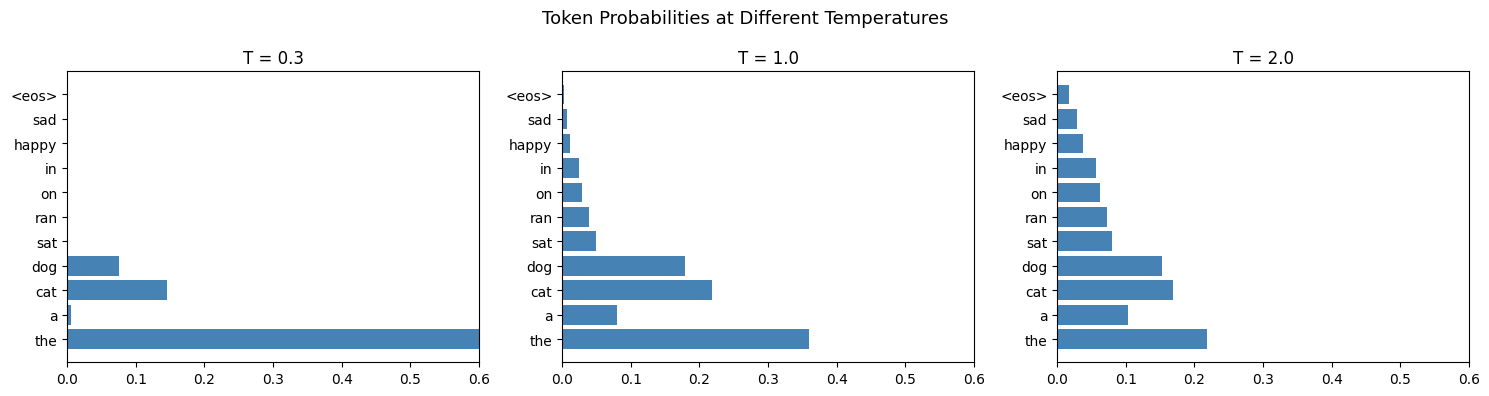


→ 圖表儲存至 llm/plots/02_generation_strategies.png


In [6]:
print("=" * 60)
print("5. 生成策略比較")
print("=" * 60)

# 模擬 logits
torch.manual_seed(42)
vocab_tokens = ['the', 'a', 'cat', 'dog', 'sat', 'ran', 'on', 'in',
                'happy', 'sad', '<eos>']
logits = torch.tensor([3.0, 1.5, 2.5, 2.3, 1.0, 0.8, 0.5, 0.3, -0.5, -1.0, -2.0])

print(f"下一個 token 的 logits:")
for t, l in zip(vocab_tokens, logits):
    print(f"  {t:>8s}: {l:.1f}")

# Greedy
greedy = logits.argmax()
print(f"\n1. Greedy: {vocab_tokens[greedy]}")
print("   → 永遠選最大的，確定但無聊")

# Temperature
print("\n2. Temperature Sampling:")
for temp in [0.3, 0.7, 1.0, 1.5]:
    probs = F.softmax(logits / temp, dim=0)
    top3_idx = probs.topk(3).indices
    print(f"   T={temp}: top3 = {[(vocab_tokens[i], f'{probs[i]:.2%}') for i in top3_idx]}")

# Top-k
print("\n3. Top-k Sampling:")
for k in [1, 3, 5]:
    top_vals, top_idx = logits.topk(k)
    probs = F.softmax(top_vals, dim=0)
    print(f"   k={k}: {[(vocab_tokens[top_idx[i]], f'{probs[i]:.2%}') for i in range(k)]}")

# Top-p (Nucleus)
print("\n4. Top-p (Nucleus) Sampling:")
probs = F.softmax(logits, dim=0)
sorted_probs, sorted_idx = probs.sort(descending=True)

for p in [0.5, 0.8, 0.95]:
    cumsum = sorted_probs.cumsum(0)
    cutoff = (cumsum >= p).nonzero()[0].item() + 1
    tokens_in = [(vocab_tokens[sorted_idx[i].item()], f'{sorted_probs[i]:.2%}')
                  for i in range(cutoff)]
    print(f"   p={p}: {cutoff} tokens: {tokens_in}")

# Beam Search
print("\n5. Beam Search:")
print("""
   不是一次選一個，而是同時維護 k 個候選序列
   每一步展開所有可能，保留 top-k 的序列

   Beam=1: Greedy
   Beam=3: 同時追蹤 3 個最佳序列

   常用於翻譯（需要高品質的確定性輸出）
   對話/創意生成通常用 sampling
""")

# 視覺化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

probs_list = {}
for i, temp in enumerate([0.3, 1.0, 2.0]):
    probs = F.softmax(logits / temp, dim=0).numpy()
    axes[i].barh(vocab_tokens, probs, color='steelblue')
    axes[i].set_title(f'T = {temp}')
    axes[i].set_xlim(0, 0.6)

plt.suptitle('Token Probabilities at Different Temperatures', fontsize=13)
plt.tight_layout()
plt.savefig('phase-5-modern/llm/plots/02_generation_strategies.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 llm/plots/02_generation_strategies.png")

## 6. LLM 全景圖

In [7]:
print("\n" + "=" * 60)
print("6. LLM 全景圖 — 2024-2025")
print("=" * 60)

print("""
  模型           公司      參數量     架構          開源
  ──────────────────────────────────────────────────────
  BERT           Google    340M      Encoder       ✓
  GPT-2          OpenAI    1.5B      Decoder       ✓
  GPT-3          OpenAI    175B      Decoder       ✗
  GPT-4          OpenAI    ?         Decoder(MoE?) ✗
  LLaMA-2        Meta      7-70B     Decoder       ✓
  LLaMA-3        Meta      8-405B    Decoder       ✓
  Claude 3.5     Anthropic ?         Decoder       ✗
  Gemini         Google    ?         Decoder       部分
  Mistral        Mistral   7-8x22B   Decoder(MoE)  ✓
  Qwen-2         Alibaba   7-72B     Decoder       ✓

  技術趨勢：
  1. 規模：越來越大（但也有高效小模型的趨勢）
  2. MoE (Mixture of Experts)：用更少的計算達到更好的效果
  3. 多模態：文字+圖片+音訊+影片
  4. 長上下文：4K → 32K → 128K → 1M+
  5. 推理能力：Chain-of-Thought, o1-style reasoning

  訓練 LLM 的代價：
    GPT-3: ~$4.6M (2020)
    LLaMA-65B: ~$2M (2023)
    GPT-4: 估計 $50-100M
    → 只有少數公司能做從零預訓練
    → 但微調和使用是大家都能做的！
""")


6. LLM 全景圖 — 2024-2025

  模型           公司      參數量     架構          開源
  ──────────────────────────────────────────────────────
  BERT           Google    340M      Encoder       ✓
  GPT-2          OpenAI    1.5B      Decoder       ✓
  GPT-3          OpenAI    175B      Decoder       ✗
  GPT-4          OpenAI    ?         Decoder(MoE?) ✗
  LLaMA-2        Meta      7-70B     Decoder       ✓
  LLaMA-3        Meta      8-405B    Decoder       ✓
  Claude 3.5     Anthropic ?         Decoder       ✗
  Gemini         Google    ?         Decoder       部分
  Mistral        Mistral   7-8x22B   Decoder(MoE)  ✓
  Qwen-2         Alibaba   7-72B     Decoder       ✓

  技術趨勢：
  1. 規模：越來越大（但也有高效小模型的趨勢）
  2. MoE (Mixture of Experts)：用更少的計算達到更好的效果
  3. 多模態：文字+圖片+音訊+影片
  4. 長上下文：4K → 32K → 128K → 1M+
  5. 推理能力：Chain-of-Thought, o1-style reasoning

  訓練 LLM 的代價：
    GPT-3: ~$4.6M (2020)
    LLaMA-65B: ~$2M (2023)
    GPT-4: 估計 $50-100M
    → 只有少數公司能做從零預訓練
    → 但微調和使用是大家都能做的！



## 小結

In [8]:
print("=" * 60)
print("小結")
print("=" * 60)
print("""
LLM 的核心知識：

  預訓練策略：
    MLM (BERT): 預測被 mask 的 token → 理解
    CLM (GPT):  預測下一個 token → 生成

  使用方式：
    1. Fine-tuning: 在特定資料上繼續訓練
    2. Prompting: 用自然語言指令引導模型
    3. RAG: 外接知識庫，減少幻覺

  生成控制：
    Temperature: 控制隨機程度
    Top-k: 限制候選 token 數量
    Top-p: 動態調整候選範圍
    Beam Search: 維護多個候選序列

  選模型指南：
    分類/NER → BERT/RoBERTa (微調)
    生成/對話 → GPT/Claude/LLaMA (Prompting 或微調)
    翻譯/摘要 → T5/mT5 或 GPT 類

下一步：03_finetuning_lora.py — 微調技術
""")

小結

LLM 的核心知識：

  預訓練策略：
    MLM (BERT): 預測被 mask 的 token → 理解
    CLM (GPT):  預測下一個 token → 生成

  使用方式：
    1. Fine-tuning: 在特定資料上繼續訓練
    2. Prompting: 用自然語言指令引導模型
    3. RAG: 外接知識庫，減少幻覺

  生成控制：
    Temperature: 控制隨機程度
    Top-k: 限制候選 token 數量
    Top-p: 動態調整候選範圍
    Beam Search: 維護多個候選序列

  選模型指南：
    分類/NER → BERT/RoBERTa (微調)
    生成/對話 → GPT/Claude/LLaMA (Prompting 或微調)
    翻譯/摘要 → T5/mT5 或 GPT 類

下一步：03_finetuning_lora.py — 微調技術

